# 03 - LMNet / ShapeNet benchmark

The 3DMPE paper studies how reconstruction quality scales with the **number of
points**, the **number of viewpoints**, and **point visibility** across a
curated subset of ShapeNet models (the *3D-LMNet* benchmark), reporting Chamfer
Distance, Earth Mover Distance, and ROA (Figures 3-7, 9-10).

This notebook reproduces those sweeps directly from the reconstruction pipeline
via `mpe3d.benchmark`. Every number is computed here - nothing is hand-tuned.

By default it runs on **demo shapes** (no download). Set `SHAPENET_DIR` to a
local `ShapeNetCore.v2` tree to run the real LMNet subset.

In [1]:
import os

import matplotlib.pyplot as plt

from mpe3d import benchmark, datasets
from mpe3d.visualization import plot_metric_curve

SHAPENET_DIR = os.environ.get("SHAPENET_DIR")

## The LMNet model registry

`mpe3d.datasets.LMNET_MODELS` holds the curated ShapeNet model hashes per
category; `lmnet_datasets()` turns them into ready-to-use selectors.

In [2]:
for category, hashes in datasets.LMNET_MODELS.items():
    print(f"{category:9s} {len(hashes)} models")

datasets.lmnet_datasets(per_category=1)

airplane  6 models
bench     6 models
car       5 models
chair     4 models
lamp      3 models
rifle     4 models
table     4 models
sofa      4 models


['ShapeNet:airplane:103c9e43cdf6501c62b600da24e0965',
 'ShapeNet:bench:42ffe8d78c2e8da9d40c07d3c15cc681',
 'ShapeNet:car:44f30f4c65c3142a16abce8cb03e7794',
 'ShapeNet:chair:bf91d0169eae3bfdd810b14a81e12eca',
 'ShapeNet:lamp:102273fdf8d1b90041fbc1e2da054acb',
 'ShapeNet:rifle:10cc9af8877d795c93c9577cd4b35faa',
 'ShapeNet:table:105b9a03ddfaf5c5e7828dbf1991f6a4',
 'ShapeNet:sofa:79bea3f7c72e0aae490ad276cd2af3a4']

## Choose the datasets to sweep

If a local ShapeNet tree is configured we use one model per LMNet category;
otherwise we fall back to a few demo primitives so the sweeps still run.

In [3]:
if SHAPENET_DIR:
    sweep_datasets = datasets.lmnet_datasets(per_category=1)
    DATADIR = SHAPENET_DIR
    # Points sweep values from the paper (Figure 4).
    POINTS_SWEEP = benchmark.SWEEPS["n_points"]
    print("Using LMNet subset:", len(sweep_datasets), "models")
else:
    sweep_datasets = ["demo:torus", "demo:sphere"]
    DATADIR = None
    # Capped for a fast, download-free demo (variable-projection MPSE on
    # thousands of points is slow); the CLI uses the full paper range.
    POINTS_SWEEP = {"n_points": [128, 256, 512]}
    print("SHAPENET_DIR not set - using demo shapes:", sweep_datasets)

# Keep the demo fast. Increase these for closer-to-paper results.
REPEATS = 1
MAX_ITER = 60

SHAPENET_DIR not set - using demo shapes: ['demo:torus', 'demo:sphere']


## Sweep 1 - quality vs. number of viewpoints

The paper finds 4-5 viewpoints usually suffice; quality is poor with fewer than
3 (Figure 6).

In [4]:
df_persp = benchmark.run_sweep(
    sweep_datasets, benchmark.SWEEPS["n_perspectives"],
    datadir=DATADIR, repeats=REPEATS,
    n_points=256, points_in_at_least=3, max_iter=MAX_ITER,
    variable_projection=True,
)
df_persp.head()

sweep over n_perspectives:   0%|          | 0/14 [00:00<?, ?it/s]

,dataset,category,model,n_points,n_perspectives,points_in_at_least,projection,variable_projection,rotation_axes,repeat,seed,chamfer,emd,roa,baseline_chamfer,baseline_emd,baseline_roa,final_cost,runtime_seconds
0,demo:torus,torus,,256,2,2,atleast,True,y,0,0,33.416239,24.631360,0.681714,11.359624,8.369194,0.068646,0.110552,5.912836
1,demo:torus,torus,,256,3,3,atleast,True,y,0,1,0.001507,0.000754,0.000039,3.473936,1.802393,0.033258,0.000620,5.881048
2,demo:torus,torus,,256,4,3,atleast,True,y,0,2,5.986726,4.339710,0.012553,10.624892,9.584964,0.106258,0.077955,6.235629
3,demo:torus,torus,,256,5,3,atleast,True,y,0,3,36.561649,31.137088,111075.338174,14.845792,12.325079,0.169996,469.453770,6.427714
4,demo:torus,torus,,256,6,3,atleast,True,y,0,4,11.919337,9.139408,0.024283,16.064980,11.067692,0.188160,0.063878,7.818704


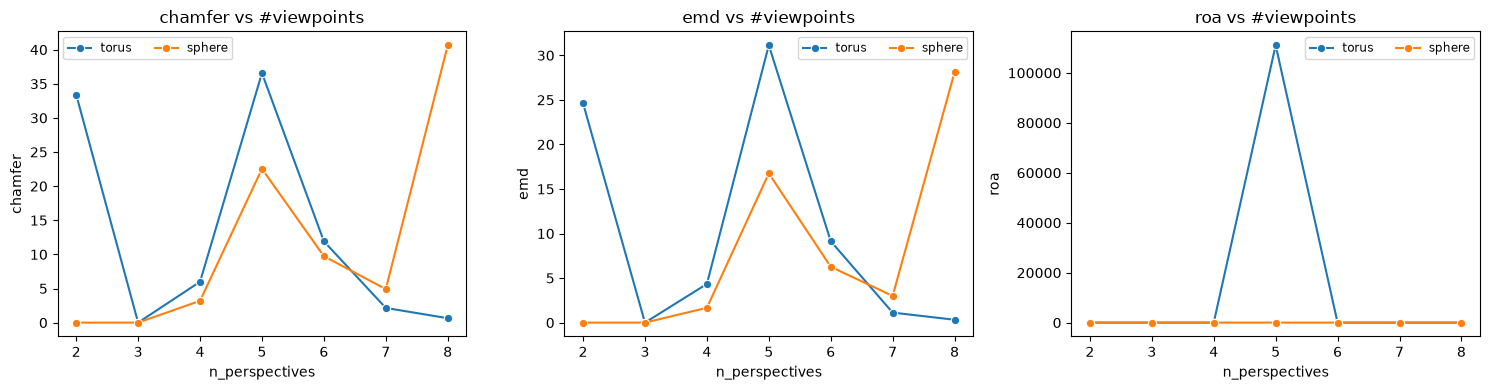

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["chamfer", "emd", "roa"]):
    plot_metric_curve(df_persp, "n_perspectives", metric, ax=ax,
                      xticks=sorted(df_persp["n_perspectives"].unique()),
                      title=f"{metric} vs #viewpoints")
plt.tight_layout()
plt.show()

## Sweep 2 - quality vs. number of points

Accuracy is largely insensitive to the number of points, while runtime grows
(Figures 3-4).

sweep over n_points:   0%|          | 0/6 [00:00<?, ?it/s]

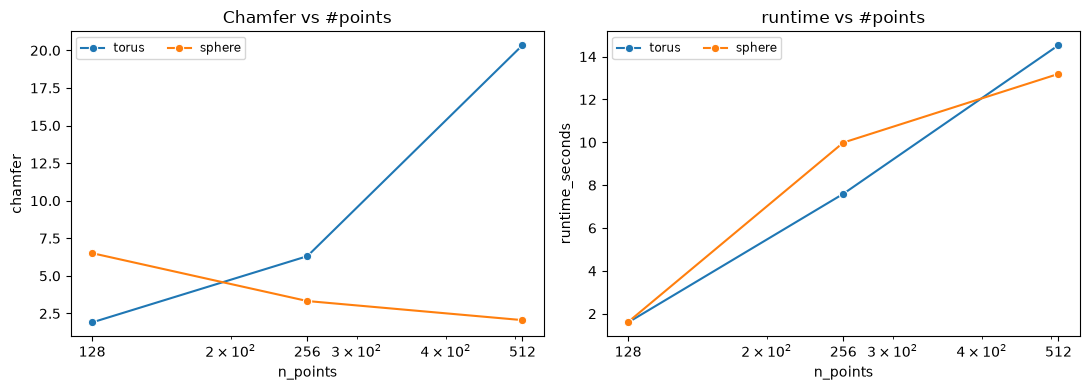

In [6]:
df_points = benchmark.run_sweep(
    sweep_datasets, POINTS_SWEEP,
    datadir=DATADIR, repeats=REPEATS,
    n_perspectives=4, points_in_at_least=3, max_iter=MAX_ITER,
    variable_projection=True,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_metric_curve(df_points, "n_points", "chamfer", ax=axes[0], logx=True,
                  xticks=sorted(df_points["n_points"].unique()),
                  title="Chamfer vs #points")
plot_metric_curve(df_points, "n_points", "runtime_seconds", ax=axes[1], logx=True,
                  xticks=sorted(df_points["n_points"].unique()),
                  title="runtime vs #points")
plt.tight_layout()
plt.show()

## Sweep 3 - quality vs. point visibility

How many viewpoints each point must appear in. 3DMPE reconstructs well once
each point is visible in **3+** views (Figure 7).

sweep over points_in_at_least:   0%|          | 0/16 [00:00<?, ?it/s]

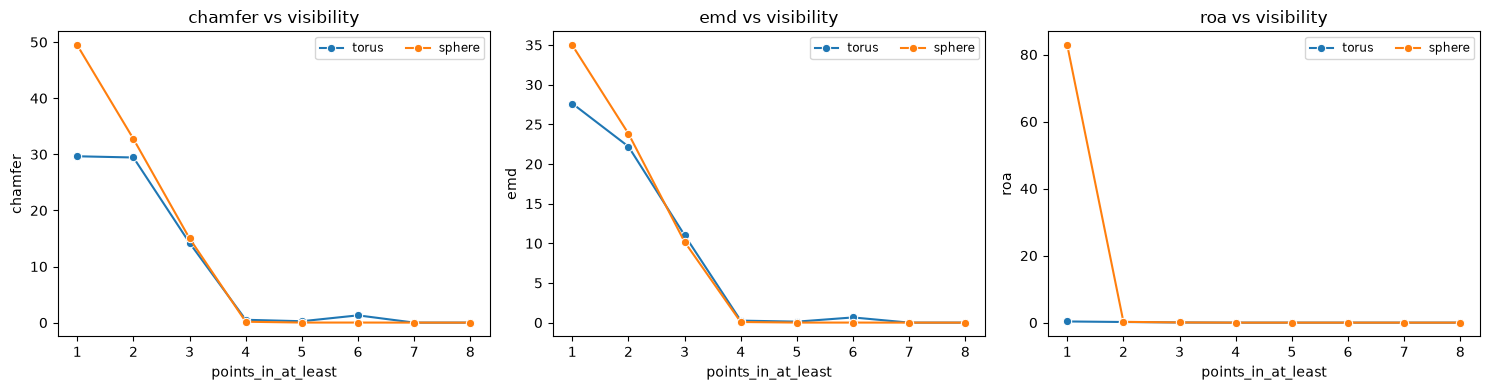

In [7]:
df_vis = benchmark.run_sweep(
    sweep_datasets, benchmark.SWEEPS["points_in_at_least"],
    datadir=DATADIR, repeats=REPEATS,
    n_points=256, n_perspectives=8, max_iter=MAX_ITER,
    variable_projection=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["chamfer", "emd", "roa"]):
    plot_metric_curve(df_vis, "points_in_at_least", metric, ax=ax,
                      xticks=sorted(df_vis["points_in_at_least"].unique()),
                      title=f"{metric} vs visibility")
plt.tight_layout()
plt.show()

## Aggregated tables

`benchmark.aggregate` reduces the per-run rows to per-category mean/spread,
ready for a paper-style table.

In [8]:
benchmark.aggregate(df_persp, "n_perspectives", "chamfer")

,category,n_perspectives,chamfer_mean,chamfer_std,chamfer_min,chamfer_max
0,sphere,2,0.001079,NaN,0.001079,0.001079
1,sphere,3,0.002150,NaN,0.002150,0.002150
2,sphere,4,3.194358,NaN,3.194358,3.194358
3,sphere,5,22.539044,NaN,22.539044,22.539044
4,sphere,6,9.740642,NaN,9.740642,9.740642
5,sphere,7,4.907981,NaN,4.907981,4.907981
6,sphere,8,40.653176,NaN,40.653176,40.653176
7,torus,2,33.416239,NaN,33.416239,33.416239
8,torus,3,0.001507,NaN,0.001507,0.001507
9,torus,4,5.986726,NaN,5.986726,5.986726


## Reproducing at scale

For the full sweeps (all LMNet models, more repeats, 300 iterations), use the
CLI, which also writes CSVs and figures:

```bash
uv run python experiments/run_lmnet_benchmark.py \
    --sweep n_perspectives --shapenet-dir /path/to/ShapeNetCore.v2 \
    --per-category 1 --repeats 3
```

Available sweeps: `n_points`, `n_perspectives`, `points_in_at_least`. Add
`--fixed-projection` for the fixed-projection setting and `--rotation-axes xyz`
for the paper's general 3-axis viewpoints.